## 1. 라이브러리 및 환경 설정

In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

from pathlib import Path

# /src 에서 실행하는 기준 경로 설정
DATA_DIR = (Path.cwd() / '../../data').resolve()
assert DATA_DIR.exists(), f"data 폴더를 찾지 못했습니다: {DATA_DIR}"
print(f"DATA_DIR: {DATA_DIR}")

# 하이퍼파라미터 설정
CFG = {
    'IMG_SIZE': 224,
    'EPOCHS': 3,
    'LEARNING_RATE': 1e-3,
    'BATCH_SIZE': 32,
    'SEED': 42
}

def seed_everything(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(CFG['SEED'])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR: /media/hdd0/whyz/structure-stability/data


## 2. 데이터 로드 및 학습/검증 데이터 분할

In [2]:
# 1. 데이터 로드
train_df = pd.read_csv(DATA_DIR / 'train.csv', encoding='utf-8-sig')
val_df = pd.read_csv(DATA_DIR / 'dev.csv', encoding='utf-8-sig')

print(f"학습 데이터 개수: {len(train_df)}")
print(f"검증 데이터 개수: {len(val_df)}")

학습 데이터 개수: 1000
검증 데이터 개수: 100


## 3. 커스텀 데이터셋 클래스 정의 및 데이터 로더

In [3]:
class MultiViewDataset(Dataset):
    def __init__(self, df, root_dir, transform=None, is_test=False):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform
        self.is_test = is_test
        self.label_map = {'stable': 0, 'unstable': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        sample_id = str(self.df.iloc[idx]['id'])
        # 폴더 경로 설정
        folder_path = os.path.join(self.root_dir, sample_id)
        
        # 2개 뷰 로드
        views = []
        for name in ["front", "top"]:
            img_path = os.path.join(folder_path, f"{name}.png")
            image = Image.open(img_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            views.append(image)
            
        # 테스트(추론) 모드일 경우 이미지 리스트만 반환
        if self.is_test:
            return views
        
        # 학습/검증 모드일 경우 라벨 함께 반환
        label = self.label_map[self.df.iloc[idx]['label']]
        return views, label

In [4]:
train_transform = transforms.Compose([
    ## Your Agumentation
    transforms.Resize((CFG['IMG_SIZE'], CFG['IMG_SIZE'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((CFG['IMG_SIZE'], CFG['IMG_SIZE'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 1. 학습/검증 세트 준비 (is_test=False 설정)
train_dataset = MultiViewDataset(train_df, str(DATA_DIR / 'train'), train_transform, is_test=False)
val_dataset = MultiViewDataset(val_df, str(DATA_DIR / 'dev'), test_transform, is_test=False)

train_loader = DataLoader(train_dataset, batch_size=CFG['BATCH_SIZE'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CFG['BATCH_SIZE'], shuffle=False)

# 2. 테스트 세트 준비 (is_test=True 설정)
test_df = pd.read_csv(DATA_DIR / 'sample_submission.csv', encoding='utf-8-sig')
test_dataset = MultiViewDataset(test_df, str(DATA_DIR / 'test'), test_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=CFG['BATCH_SIZE'], shuffle=False)

## 4. 모델 정의 (Multi-View )

In [5]:
class MultiViewResNet(nn.Module):
    def __init__(self, num_classes=1):
        super(MultiViewResNet, self).__init__()
        self.backbone = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        self.feature_extractor = nn.Sequential(*list(self.backbone.children())[:-1])
        
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, views):
        # views: [batch, 3, 224, 224] * 2 images
        f1 = self.feature_extractor(views[0]).view(views[0].size(0), -1)
        f2 = self.feature_extractor(views[1]).view(views[1].size(0), -1)
        
        combined = torch.cat((f1, f2), dim=1)
        return self.classifier(combined)

## 4. 학습 및 검증 루프 구현

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    train_loss = 0
    for views, labels in tqdm(loader, desc="Training"):
        views = [v.to(device) for v in views]
        labels = labels.to(device).float()
        
        optimizer.zero_grad()
        outputs = model(views).view(-1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    return train_loss / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for views, labels in tqdm(loader, desc="Validation"):
            views = [v.to(device) for v in views]
            labels = labels.to(device).float()
            
            outputs = model(views).view(-1)
            # 1. 시그모이드를 통과시켜 확률값(unstable일 확률)으로 변환
            probs = torch.sigmoid(outputs)
            
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_probs = np.array(all_probs, dtype=np.float64)
    all_labels = np.array(all_labels, dtype=np.float64)
    
    # 대회 공식 LOGLOSS 계산
    eps = 1e-15
    p = np.clip(all_probs, eps, 1 - eps)
    # Binary Log Loss 공식 직접 적용
    logloss_score = -np.mean(all_labels * np.log(p) + (1 - all_labels) * np.log(1 - p))
    
    # Accuracy 계산
    acc_score = np.mean((all_probs > 0.5) == all_labels)
    
    return logloss_score, acc_score

In [7]:
model = MultiViewResNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=CFG['LEARNING_RATE'])

best_logloss = float('inf')
best_epoch = -1
best_model_path = Path('best_model.pt')

# --- Main Loop ---
for epoch in range(1, CFG['EPOCHS'] + 1):
    avg_train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_logloss, val_acc = validate(model, val_loader, criterion, device)

    if val_logloss < best_logloss:
        best_logloss = val_logloss
        best_epoch = epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_logloss': val_logloss,
            'val_acc': val_acc,
            'cfg': CFG,
        }, best_model_path)
        print(f"  -> Best model saved: {best_model_path} (epoch={epoch}, val_logloss={val_logloss:.6f})")

    print(f"Epoch [{epoch}]")
    print(f"  - Train Loss: {avg_train_loss:.4f}")
    print(f"  - Val Log-Loss: {val_logloss:.6f} | Val Acc: {val_acc:.4f}")

# 학습 종료 후 best 가중치 로드
if best_model_path.exists():
    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Best model loaded from {best_model_path} (epoch={checkpoint['epoch']}, val_logloss={checkpoint['val_logloss']:.6f})")



Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch [1]
  - Train Loss: 0.1207
  - Val Log-Loss: 1.241040 | Val Acc: 0.7800


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch [2]
  - Train Loss: 0.0001
  - Val Log-Loss: 1.998559 | Val Acc: 0.7200


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch [3]
  - Train Loss: 0.0001
  - Val Log-Loss: 1.672000 | Val Acc: 0.7400


## 5. 검증셋 오답 확인

학습된 모델이 `dev`에서 틀린 샘플을 표와 이미지로 확인합니다.

In [8]:
model.eval()
val_probs = []

with torch.no_grad():
    for views, _ in tqdm(val_loader, desc="Validate Error Analysis"):
        views = [v.to(device) for v in views]
        outputs = model(views).view(-1)
        probs = torch.sigmoid(outputs)
        val_probs.extend(probs.cpu().numpy())

val_probs = np.array(val_probs)

val_result = val_df.copy().reset_index(drop=True)
val_result['unstable_prob'] = val_probs
val_result['stable_prob'] = 1.0 - val_probs
val_result['pred_label'] = np.where(val_result['unstable_prob'] > 0.5, 'unstable', 'stable')

mistakes = val_result[val_result['pred_label'] != val_result['label']].copy()
mistakes['pred_confidence'] = np.where(
    mistakes['pred_label'] == 'unstable',
    mistakes['unstable_prob'],
    mistakes['stable_prob']
)
mistakes = mistakes.sort_values('pred_confidence', ascending=False).reset_index(drop=True)

print(f"오답 개수: {len(mistakes)} / {len(val_result)}")
display(mistakes[['id', 'label', 'pred_label', 'unstable_prob', 'stable_prob', 'pred_confidence']].head(20))



Validate Error Analysis:   0%|          | 0/4 [00:00<?, ?it/s]

오답 개수: 26 / 100


,id,label,pred_label,unstable_prob,stable_prob,pred_confidence
0,DEV_045,stable,unstable,0.999999,0.000001,0.999999
1,DEV_005,stable,unstable,0.999980,0.000020,0.999980
2,DEV_059,stable,unstable,0.999976,0.000024,0.999976
3,DEV_090,unstable,stable,0.000054,0.999946,0.999946
4,DEV_084,stable,unstable,0.999895,0.000105,0.999895
5,DEV_027,stable,unstable,0.999877,0.000123,0.999877
6,DEV_092,unstable,stable,0.000169,0.999831,0.999831
7,DEV_058,unstable,stable,0.000374,0.999626,0.999626
8,DEV_085,stable,unstable,0.999358,0.000642,0.999358
9,DEV_067,stable,unstable,0.999114,0.000886,0.999114


/home/dblab/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-a9dcn4gk because there was an issue with the default path (/home/dblab/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


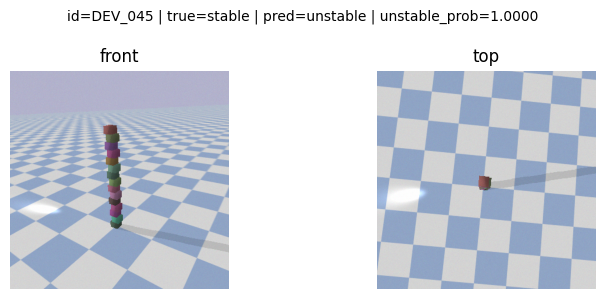

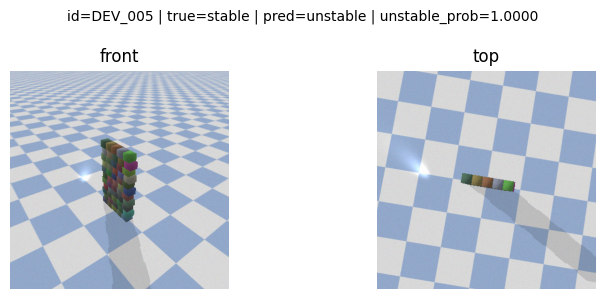

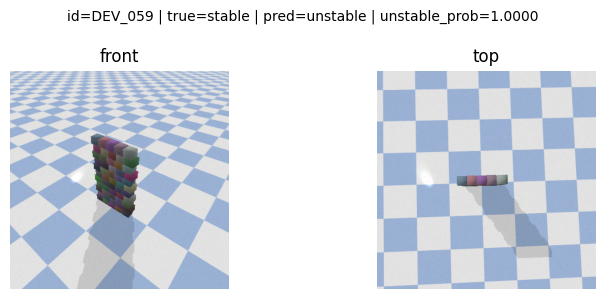

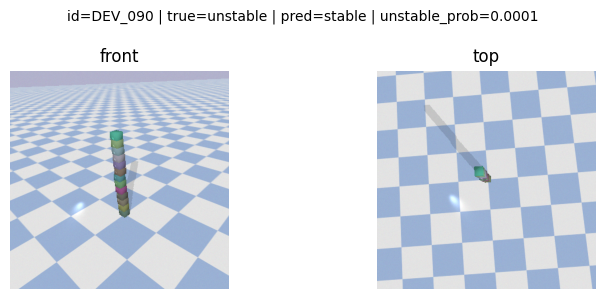

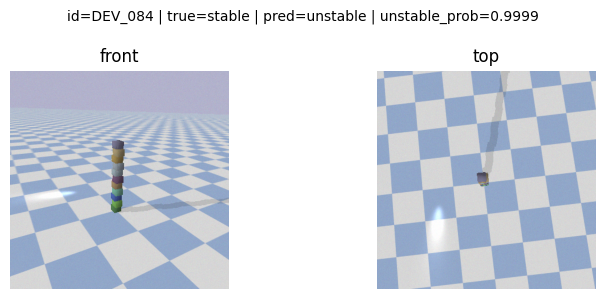

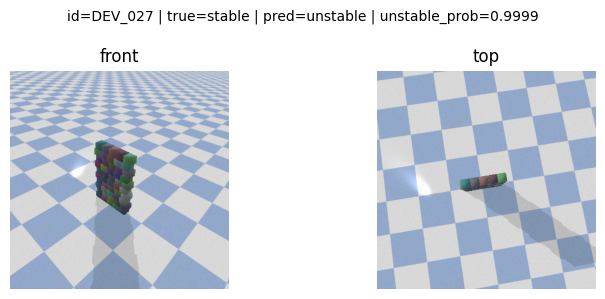

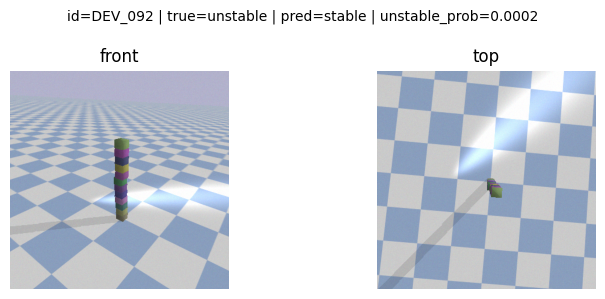

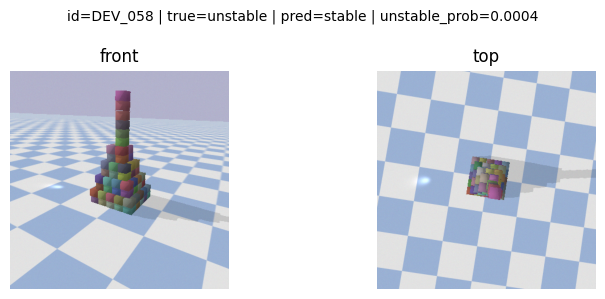

In [9]:
import matplotlib.pyplot as plt

TOP_N = 8  # 시각화할 오답 샘플 수
show_df = mistakes.head(TOP_N)

for _, row in show_df.iterrows():
    sample_id = row['id']
    front_path = DATA_DIR / 'dev' / sample_id / 'front.png'
    top_path = DATA_DIR / 'dev' / sample_id / 'top.png'

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].imshow(Image.open(front_path).convert('RGB'))
    axes[0].set_title('front')
    axes[0].axis('off')

    axes[1].imshow(Image.open(top_path).convert('RGB'))
    axes[1].set_title('top')
    axes[1].axis('off')

    fig.suptitle(
        f"id={sample_id} | true={row['label']} | pred={row['pred_label']} | unstable_prob={row['unstable_prob']:.4f}",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()



## 5. 추론 및 제출 파일 생성

In [10]:
model.eval()
all_probs = []

with torch.no_grad():
    for views in tqdm(test_loader, desc="Inference"):
        views = [v.to(device) for v in views]
        
        # 모델 출력 (Logit) -> 시그모이드 -> unstable(1)일 확률
        outputs = model(views).view(-1)
        probs = torch.sigmoid(outputs)
        
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)
# 결과 저장 (컬럼  순서 중요)
submission = pd.DataFrame({
    'id': test_df['id'],
    'unstable_prob': all_probs,  # unstable일 확률 저장
    'stable_prob': 1.0 - all_probs # stable일 확률 저장
})

submission.to_csv('submission.csv', encoding='UTF-8-sig', index=False)
print("submission.csv 저장 완료.")

Inference:   0%|          | 0/32 [00:00<?, ?it/s]

submission.csv 저장 완료.
